# 01 · Vida e RUL do Maintacker — Weibull

**Objetivo:** estimar a vida atual e a vida restante do rolo maintacker usando a
distribuição de Weibull calibrada sobre ciclos genuínos.

**Saída principal:** `01_vida_rul.csv` com as colunas que alimentam o Eixo 1 do
`trigger_engine.py` — em especial `score_roll7d`, a suavização 7 dias da CDF Weibull.

```
horas_desde_troca  →  score_weibull = F_weibull(h)  →  score_roll7d (média 7d)
                   →  rul_p10 / rul_p50 / rul_p90 (RUL condicional)
```

| Etapa | Descrição |
|---|---|
| A | Carregar dados e calcular `horas_desde_troca` por ciclo |
| B | Identificar ciclos genuínos (`target_rul < 20 h` na troca) e refit Weibull |
| C | Calcular `score_weibull` e `score_roll7d` |
| D | Calcular RUL condicional P10 / P50 / P90 |
| E | Validação visual e tabela de antecedência por ciclo |
| F | Exportar `01_vida_rul.csv` e `01_weibull_params.json` |

In [1]:
import sys, json, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ── Configurações ────────────────────────────────────────────────────────────
LIMIAR_GENUINO_H  = 20        # target_rul < N horas na troca → ciclo genuíno
ARQUIVO_HOURLY    = '00_hour_prev.csv'
ARQUIVO_TROCAS    = 'troca_modulo.csv'
COLUNA_DATA_TROCA = 'Data-base do inicio'
SCORE_CRITICO     = 0.60      # threshold Eixo 1 do trigger engine
WINDOW_SCORE_7D   = '7D'      # janela de suavização do score
ARQUIVO_DELAY     = 'anomaly_delay.csv'   # stopped_h cumulativo por ciclo
# ─────────────────────────────────────────────────────────────────────────────
print('Configurações OK')

Configurações OK


## Etapa A — Carregar dados e calcular `horas_desde_troca`

In [2]:
df = pd.read_csv(ARQUIVO_HOURLY, parse_dates=['Timestamp'])
df = df.rename(columns={'Timestamp': 'ts'})
df['ts'] = pd.to_datetime(df['ts'], utc=True)
df['rul'] = pd.to_numeric(df['target_rul'], errors='coerce')
df = df.sort_values('ts').reset_index(drop=True)

# Sincronizar troca_modulo.csv do SharePoint antes de carregar
from src.sp_troca_sync import sync_troca_modulo
try:
    sync_troca_modulo()
except Exception as _e:
    print(f'⚠️  sp_troca_sync: {_e}')

# Carregar datas de troca e normalizar timezone
tc = pd.read_csv(ARQUIVO_TROCAS, parse_dates=[COLUNA_DATA_TROCA])
tc = tc.sort_values(COLUNA_DATA_TROCA).reset_index(drop=True)
troca_dates = pd.to_datetime(tc[COLUNA_DATA_TROCA]).dt.tz_localize('UTC').tolist()

# ── Dados de delay (stopped_h cumulativo por ciclo) ──────────────────────────
try:
    _delay = pd.read_csv(ARQUIVO_DELAY, parse_dates=['Timestamp'])
    _delay['ts'] = pd.to_datetime(_delay['Timestamp'], utc=True)
    _delay = _delay.sort_values('ts').reset_index(drop=True)
    # stopped_h máximo por janela de tempo (não por ciclo_id, pois indexação pode diferir)
    _delay_by_ts = _delay.set_index('ts').sort_index()
    HAS_DELAY = True
    _delay_stopped = {}   # preenchido por janela de troca em cell 6
    print(f'anomaly_delay  : {len(_delay)} pts | range: {_delay["ts"].min().date()} → {_delay["ts"].max().date()}')
except FileNotFoundError:
    _delay, _delay_stopped, HAS_DELAY = None, {}, False
    print('⚠️  anomaly_delay.csv ausente — Weibull usará tempo calendário')

print(f'Dados horários : {len(df)} linhas  |  '
      f'{df["ts"].min().date()} → {df["ts"].max().date()}')
print(f'Trocas no CSV  : {len(troca_dates)}  '
      f'(última: {troca_dates[-1].date()})')

KeyError: 'target_rul'

In [ ]:
# Atribuir cada hora ao seu ciclo e calcular horas_desde_troca
# Ciclo i: de troca_dates[i] até troca_dates[i+1]-1h
# Ciclo atual (aberto): de troca_dates[-1] em diante

df['horas_desde_troca'] = np.nan
df['ciclo_id']          = -1

limites = troca_dates + [pd.Timestamp.max.tz_localize('UTC')]

for i, (t_ini, t_fim) in enumerate(zip(limites[:-1], limites[1:])):
    mask = (df['ts'] >= t_ini) & (df['ts'] < t_fim)
    if not mask.any():
        continue
    elapsed = (df.loc[mask, 'ts'] - t_ini).dt.total_seconds() / 3600
    df.loc[mask, 'horas_desde_troca'] = elapsed.values
    df.loc[mask, 'ciclo_id']          = i

atribuidas = (df['ciclo_id'] >= 0).sum()
print(f'Horas com ciclo atribuído : {atribuidas} / {len(df)}')
print(f'Ciclos distintos          : {df["ciclo_id"].nunique() - 1}  + ciclo atual')

# Horas operacionais desde troca = horas calendário − stopped_h cumulativo
# Backward merge com anomaly_delay (tolerância 12h entre registros)
df['horas_op_desde_troca'] = df['horas_desde_troca'].copy()
if HAS_DELAY and _delay is not None:
    # Merge por timestamp; stopped_h é cumulativo DENTRO do ciclo do delay
    # Não usar ciclo_id pois a indexação pode diferir entre datasets
    # Usar apenas registros onde o delay veio de dentro da mesma janela de troca
    _d = _delay[['ts', 'stopped_h']].sort_values('ts')
    _left = df[['ts', 'ciclo_id', 'horas_desde_troca']].sort_values('ts').reset_index()
    _m = pd.merge_asof(_left, _d, on='ts', tolerance=pd.Timedelta('12h'), direction='backward')
    # Garantir que o registro de delay está dentro da mesma janela de troca
    # Reconstruir t_inicio de cada linha usando ciclo_id → troca_dates
    _ciclo_ini = {i: troca_dates[i] for i in range(len(troca_dates))}
    _m['_t_ciclo_ini'] = _m['ciclo_id'].map(_ciclo_ini)
    # delay válido: ts_delay >= t_inicio do ciclo (evita vazar stopped_h de ciclo anterior)
    _delay_ts_match = pd.merge_asof(_left, _d.rename(columns={'ts':'_ts_delay','stopped_h':'_sh_raw'}),
                                     left_on='ts', right_on='_ts_delay',
                                     tolerance=pd.Timedelta('12h'), direction='backward')
    _valid = (
        _delay_ts_match['_sh_raw'].notna() &
        (_delay_ts_match['_ts_delay'] >= _delay_ts_match['ciclo_id'].map(_ciclo_ini).fillna(pd.Timestamp.min.tz_localize('UTC')))
    )
    _op_h = (_m['horas_desde_troca'] - _delay_ts_match['_sh_raw'].fillna(0)).clip(lower=0)
    df.loc[_left.loc[_valid, 'index'].values, 'horas_op_desde_troca'] = _op_h[_valid].values
    print(f'horas_op_desde_troca     : {int(_valid.sum())} linhas com stopped_h do delay'
          f' | {int((~_valid).sum())} em calendário (sem cobertura)')
else:
    print('horas_op_desde_troca     : igual a horas_desde_troca (sem delay)')

print(f'\nCiclo atual — início: {troca_dates[-1].date()}  '
      f'| horas operacionais: {df[df["ciclo_id"]==(len(troca_dates)-1)]["horas_op_desde_troca"].max():.0f}h')

Horas com ciclo atribuído : 2978 / 2978
Ciclos distintos          : 28  + ciclo atual

Ciclo atual — início: 2026-05-06  | horas decorridas: nanh


## Etapa B — Ciclos genuínos e refit Weibull

**Critério de genuinidade:** `target_rul < 20h` na última hora antes da troca  
→ o rolo estava com vida quase zerada, portanto a troca foi por desgaste real, não preventiva.

In [ ]:
ciclos = []

for i, (t_ini, t_fim_troca) in enumerate(zip(troca_dates[:-1], troca_dates[1:])):
    # Última hora do ciclo = última linha antes da próxima troca
    mask_ciclo = (df['ts'] >= t_ini) & (df['ts'] < t_fim_troca)
    ciclo_df   = df[mask_ciclo]
    if ciclo_df.empty:
        continue

    duracao_h        = ciclo_df['horas_desde_troca'].max()
    # stopped_h total no ciclo: max(stopped_h) em [t_ini, t_fim] no delay
    if HAS_DELAY and _delay is not None:
        _mask_del = (_delay['ts'] >= t_ini) & (_delay['ts'] < t_fim_troca)
        stopped_h_ciclo = float(_delay.loc[_mask_del, 'stopped_h'].max()) if _mask_del.any() else 0.0
    else:
        stopped_h_ciclo = 0.0
    duracao_op_h     = max(1.0, duracao_h - stopped_h_ciclo) if pd.notna(duracao_h) else np.nan
    rul_restante     = ciclo_df['rul'].iloc[-1]
    genuino          = pd.notna(rul_restante) and rul_restante < LIMIAR_GENUINO_H

    ciclos.append({
        'ciclo_id'        : i,
        'troca_inicio'    : t_ini.date(),
        'troca_fim'       : t_fim_troca.date(),
        'duracao_h'       : round(duracao_h, 1)    if pd.notna(duracao_h) else np.nan,
        'duracao_dias'    : round(duracao_h / 24, 1) if pd.notna(duracao_h) else np.nan,
        'stopped_h_ciclo' : round(stopped_h_ciclo, 1),
        'duracao_op_h'    : round(duracao_op_h, 1) if pd.notna(duracao_op_h) else np.nan,
        'duracao_op_dias' : round(duracao_op_h / 24, 1) if pd.notna(duracao_op_h) else np.nan,
        'rul_restante_h'  : round(rul_restante, 1) if pd.notna(rul_restante) else np.nan,
        'genuino'         : genuino,
    })

ciclos_df = pd.DataFrame(ciclos)
genuinos  = ciclos_df[ciclos_df['genuino'] & ciclos_df['duracao_op_h'].notna() & (ciclos_df['duracao_op_h'] > 0)]
duracoes_h = genuinos['duracao_op_h'].values  # ← tempo operacional para ajuste Weibull

print(f'Ciclos completos detectados : {len(ciclos_df)}')
print(f'Genuínos (target_rul<{LIMIAR_GENUINO_H}h)  : {len(genuinos)}')
print(f'Prematuros / preventivos    : {len(ciclos_df) - len(genuinos)}')
print()
print(f'Duração genuínos — min: {duracoes_h.min():.0f}h  '
      f'mediana: {np.median(duracoes_h):.0f}h ({np.median(duracoes_h)/24:.1f}d)  '
      f'max: {duracoes_h.max():.0f}h')
print()
display(ciclos_df[['ciclo_id', 'troca_inicio', 'troca_fim',
                    'duracao_dias', 'rul_restante_h', 'genuino']])

Ciclos completos detectados : 29
Genuínos (target_rul<20h)  : 22
Prematuros / preventivos    : 7

Duração genuínos — min: 22h  mediana: 671h (28.0d)  max: 4439h



,ciclo_id,troca_inicio,troca_fim,duracao_dias,rul_restante_h,genuino
0,1,2022-06-23,2022-08-19,56.6,9.7,True
1,2,2022-08-19,2022-10-13,51.9,73.9,False
2,3,2022-10-13,2022-11-30,47.9,1.9,True
3,4,2022-11-30,2022-12-16,15.6,9.9,True
4,5,2022-12-16,2023-02-23,61.3,3161.4,False
5,6,2023-02-23,2023-05-12,77.9,1105.5,False
6,7,2023-05-12,2023-06-26,44.6,33.8,False
7,8,2023-06-26,2023-06-27,0.9,1.8,True
8,9,2023-06-27,2023-12-26,179.7,55.7,False
9,10,2023-12-26,2024-01-22,26.7,8.3,True


In [ ]:
# Ajuste Weibull de dois parâmetros (loc=0 fixo)
beta, _, eta = stats.weibull_min.fit(duracoes_h, floc=0)

vida_p10 = stats.weibull_min.ppf(0.10, beta, loc=0, scale=eta)
vida_p50 = stats.weibull_min.ppf(0.50, beta, loc=0, scale=eta)
vida_p90 = stats.weibull_min.ppf(0.90, beta, loc=0, scale=eta)
vida_mttf = stats.weibull_min.mean(beta, loc=0, scale=eta)

# Hora em que CDF cruza o limiar do trigger
h_score_critico = stats.weibull_min.ppf(SCORE_CRITICO, beta, loc=0, scale=eta)

print('=' * 52)
print('  WEIBULL — RESULTADO DO AJUSTE')
print('=' * 52)
print(f'  β (shape) = {beta:.4f}  |  η (scale) = {eta:.1f}h')
print()
print(f'  P10  :  {vida_p10:.0f}h  ({vida_p10/24:.1f} dias)')
print(f'  P50  :  {vida_p50:.0f}h  ({vida_p50/24:.1f} dias)')
print(f'  MTTF :  {vida_mttf:.0f}h  ({vida_mttf/24:.1f} dias)')
print(f'  P90  :  {vida_p90:.0f}h  ({vida_p90/24:.1f} dias)')
print()
print(f'  score_weibull cruza {SCORE_CRITICO:.0%} em  →  '
      f'{h_score_critico:.0f}h  ({h_score_critico/24:.1f} dias)')
print('=' * 52)

  WEIBULL — RESULTADO DO AJUSTE
  β (shape) = 1.2116  |  η (scale) = 1057.3h

  P10  :  165h  (6.9 dias)
  P50  :  781h  (32.6 dias)
  MTTF :  992h  (41.3 dias)
  P90  :  2105h  (87.7 dias)

  score_weibull cruza 60% em  →  984h  (41.0 dias)


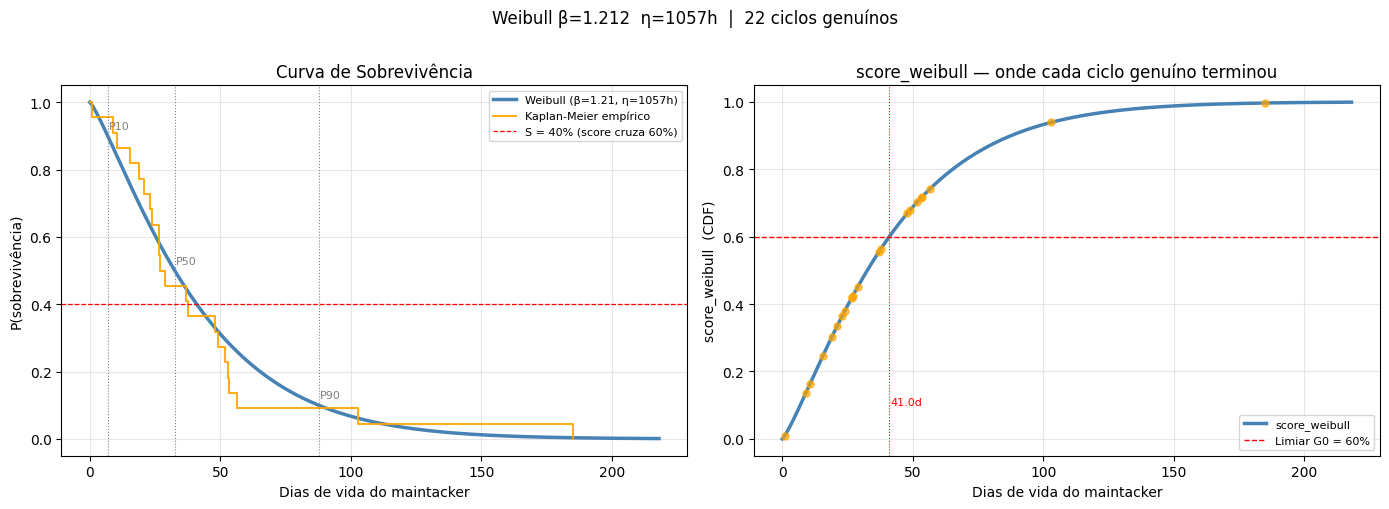

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

t_max   = np.percentile(duracoes_h, 99) * 1.3
t_range = np.linspace(0.1, t_max, 800)
S_fit   = stats.weibull_min.sf(t_range, beta, loc=0, scale=eta)
F_fit   = 1 - S_fit

# Kaplan-Meier empírico
n  = len(duracoes_h)
sd = np.sort(duracoes_h)
km_t = np.concatenate([[0], sd])
km_s = np.concatenate([[1.0], [(n - i) / n for i in range(1, n + 1)]])

# Sobrevivência
axes[0].plot(t_range / 24, S_fit, lw=2.5, color='steelblue',
             label=f'Weibull (β={beta:.2f}, η={eta:.0f}h)')
axes[0].step(km_t / 24, km_s, where='post', color='orange', lw=1.5, alpha=0.9,
             label='Kaplan-Meier empírico')
for p, lbl in [(0.9, 'P10'), (0.5, 'P50'), (0.1, 'P90')]:
    tp = stats.weibull_min.ppf(1 - p, beta, loc=0, scale=eta)
    axes[0].axvline(tp / 24, color='gray', ls=':', lw=0.8)
    axes[0].text(tp / 24 + 0.3, p + 0.02, lbl, fontsize=8, color='gray')
axes[0].axhline(1 - SCORE_CRITICO, color='red', ls='--', lw=0.9,
                label=f'S = {1-SCORE_CRITICO:.0%} (score cruza {SCORE_CRITICO:.0%})')
axes[0].set_xlabel('Dias de vida do maintacker')
axes[0].set_ylabel('P(sobrevivência)')
axes[0].set_title('Curva de Sobrevivência')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# CDF = score_weibull
axes[1].plot(t_range / 24, F_fit, lw=2.5, color='steelblue', label='score_weibull')
axes[1].axhline(SCORE_CRITICO, color='red', ls='--', lw=1.0,
                label=f'Limiar G0 = {SCORE_CRITICO:.0%}')
axes[1].axvline(h_score_critico / 24, color='red', ls=':', lw=0.8)
axes[1].text(h_score_critico / 24 + 0.5, 0.1,
             f'{h_score_critico/24:.1f}d', color='red', fontsize=8)
for dur in duracoes_h:
    score_fim = stats.weibull_min.cdf(dur, beta, loc=0, scale=eta)
    axes[1].scatter(dur / 24, score_fim, color='orange', s=25, alpha=0.7, zorder=3)
axes[1].set_xlabel('Dias de vida do maintacker')
axes[1].set_ylabel('score_weibull  (CDF)')
axes[1].set_title(f'score_weibull — onde cada ciclo genuíno terminou')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.suptitle(f'Weibull β={beta:.3f}  η={eta:.0f}h  |  {len(duracoes_h)} ciclos genuínos', y=1.01)
plt.tight_layout()
plt.savefig('01_weibull_fit.png', dpi=120, bbox_inches='tight')
plt.show()

## Etapa C — `score_weibull` e `score_roll7d`

`score_weibull = F_weibull(horas_desde_troca)` — sobe deterministicamente com a idade,
independente dos sinais de força. Cruzar 0.60 significa que o rolo está na faixa em que
60% dos maintackers históricos já foram trocados.

`score_roll7d` = média 7 dias do score horário → entrada do Eixo 1 do trigger engine.
A suavização elimina artefatos de resets de ciclo.

In [ ]:
valid = df['horas_op_desde_troca'].notna() & (df['horas_op_desde_troca'] >= 0)
h = df.loc[valid, 'horas_op_desde_troca'].values

df.loc[valid, 'score_weibull'] = stats.weibull_min.cdf(h, beta, loc=0, scale=eta)

# Suavização 7 dias — reseta no início de cada ciclo para não vazar entre ciclos
score_roll = np.full(len(df), np.nan)
for ciclo_id in df['ciclo_id'].unique():
    if ciclo_id < 0:
        continue
    mask_ciclo = df['ciclo_id'] == ciclo_id
    s = df.loc[mask_ciclo, 'score_weibull']
    if s.notna().sum() == 0:
        continue
    s_indexed = s.copy()
    s_indexed.index = df.loc[mask_ciclo, 'ts']
    rolled = s_indexed.rolling(WINDOW_SCORE_7D, min_periods=1).mean().values
    score_roll[mask_ciclo.values] = rolled

df['score_roll7d'] = score_roll

# Diagnóstico
ultimo = df[valid].iloc[-1]
print('── Estado atual do ciclo ───────────────────────────────')
print(f'  Timestamp          : {ultimo["ts"]}')
print(f'  horas_op_desde_troca : {ultimo["horas_op_desde_troca"]:.1f}h  '
      f'({ultimo["horas_op_desde_troca"]/24:.1f} dias op | calendário: {ultimo["horas_desde_troca"]:.0f}h)')
print(f'  score_weibull      : {ultimo["score_weibull"]:.4f}')
_nivel_score = 'ACIMA' if ultimo['score_roll7d'] >= SCORE_CRITICO else 'abaixo'
print(f'  score_roll7d       : {ultimo["score_roll7d"]:.4f}  '
      f'({_nivel_score} do limiar {SCORE_CRITICO:.0%})')
print()
print(f'  score_roll7d cruza {SCORE_CRITICO:.0%} a partir de ~{h_score_critico:.0f}h op'
      f' ({h_score_critico/24:.1f} dias operacionais) de vida do rolo')

── Estado atual do ciclo ───────────────────────────────
  Timestamp          : 2026-05-05 23:02:22+00:00
  horas_desde_troca  : 551.0h  (23.0 dias)
  score_weibull      : 0.3649
  score_roll7d       : 0.3133  (abaixo do limiar 60%)

  score_roll7d cruza 60% a partir de ~984h (41.0 dias) de vida do rolo


## Etapa D — RUL condicional P10 / P50 / P90

Dado que o rolo sobreviveu `h` horas, qual a vida restante esperada?

```
p_atual  = F(h)
p_alvo_q = p_atual + (1 - p_atual) × q
RUL_q    = F⁻¹(p_alvo_q) − h
```

In [ ]:
def rul_condicional(h_arr, q):
    p_atual = stats.weibull_min.cdf(h_arr, beta, loc=0, scale=eta)
    p_alvo  = np.minimum(p_atual + (1 - p_atual) * q, 0.9999)
    t_alvo  = stats.weibull_min.ppf(p_alvo, beta, loc=0, scale=eta)
    return np.maximum(0.0, t_alvo - h_arr)

df.loc[valid, 'rul_p10'] = rul_condicional(h, 0.10)
df.loc[valid, 'rul_p50'] = rul_condicional(h, 0.50)
df.loc[valid, 'rul_p90'] = rul_condicional(h, 0.90)

print('RUL condicional — últimas 3 leituras:')
display(df.loc[valid, ['ts', 'horas_desde_troca', 'score_roll7d',
                         'rul_p10', 'rul_p50', 'rul_p90']].tail(3).round(1))

RUL condicional — últimas 3 leituras:


,ts,horas_desde_troca,score_roll7d,rul_p10,rul_p50,rul_p90
2975,2026-05-05 07:02:47+00:00,535.0,0.3,104.2,635.6,1894.9
2976,2026-05-05 15:04:59+00:00,543.1,0.3,103.9,634.4,1892.7
2977,2026-05-05 23:02:22+00:00,551.0,0.3,103.6,633.2,1890.6


## Etapa E — Antecedência do score_roll7d por ciclo

Para cada ciclo genuíno: **quantos dias antes da troca o score_roll7d cruzou 0.60?**  
Ciclos em que o score nunca cruzou 0.60 são "silenciosos" pelo Eixo 1 — serão detectados
pelo Eixo 2 (sinais de força) ou ficarão no relatório periódico.

In [ ]:
antecedencia = []

for _, row in genuinos.iterrows():
    cid = row['ciclo_id']
    t_fim = pd.Timestamp(row['troca_fim']).tz_localize('UTC')
    ciclo_df = df[(df['ciclo_id'] == cid) & df['score_roll7d'].notna()].copy()
    if ciclo_df.empty:
        continue

    acima = ciclo_df[ciclo_df['score_roll7d'] >= SCORE_CRITICO]
    if acima.empty:
        antecedencia_dias = None
        primeiro_cruzamento = None
    else:
        primeiro_cruzamento = acima.iloc[0]['ts']
        antecedencia_dias   = (t_fim - primeiro_cruzamento).total_seconds() / 86400

    antecedencia.append({
        'ciclo_id'           : cid,
        'troca_fim'          : row['troca_fim'],
        'duracao_dias'        : round(row['duracao_h'] / 24, 1),
        'score_no_fim'       : round(ciclo_df.iloc[-1]['score_roll7d'], 3),
        'cruzou_limiar'      : acima.shape[0] > 0,
        'primeiro_cruzamento': primeiro_cruzamento,
        'antecedencia_dias'  : round(antecedencia_dias, 1) if antecedencia_dias else None,
    })

ant_df = pd.DataFrame(antecedencia)
cruzou = ant_df['cruzou_limiar'].sum()
silencioso = len(ant_df) - cruzou

print(f'Ciclos genuínos analisados : {len(ant_df)}')
print(f'  score_roll7d cruzou 0.60 : {cruzou}  '
      f'({cruzou/len(ant_df):.0%} de cobertura pelo Eixo 1)')
print(f'  Silenciosos (Eixo 1)     : {silencioso}  '
      f'(detectados pelo Eixo 2 ou relatório periódico)')
if cruzou > 0:
    ants = ant_df.loc[ant_df['cruzou_limiar'], 'antecedencia_dias'].dropna()
    print(f'  Antecedência — mediana: {ants.median():.1f}d  '
          f'min: {ants.min():.1f}d  max: {ants.max():.1f}d')
print()
display(ant_df)

Ciclos genuínos analisados : 22
  score_roll7d cruzou 0.60 : 8  (36% de cobertura pelo Eixo 1)
  Silenciosos (Eixo 1)     : 14  (detectados pelo Eixo 2 ou relatório periódico)
  Antecedência — mediana: 9.2d  min: 3.4d  max: 137.7d



,ciclo_id,troca_fim,duracao_dias,score_no_fim,cruzou_limiar,primeiro_cruzamento,antecedencia_dias
0,1,2022-08-19,56.6,0.714,True,2022-08-06 14:14:01+00:00,12.4
1,3,2022-11-30,47.9,0.635,True,2022-11-26 14:23:01+00:00,3.4
2,4,2022-12-16,15.6,0.182,False,NaT,NaN
3,8,2023-06-27,0.9,0.006,False,NaT,NaN
4,10,2024-01-22,26.7,0.358,False,NaT,NaN
5,11,2024-03-16,53.4,0.689,True,2024-03-06 00:38:01+00:00,10.0
6,12,2024-05-07,51.7,0.688,True,2024-05-03 08:45:02+00:00,3.6
7,13,2024-06-14,37.7,0.515,False,NaT,NaN
8,14,2024-07-11,27.0,0.385,False,NaT,NaN
9,15,2024-08-17,37.0,0.511,False,NaT,NaN


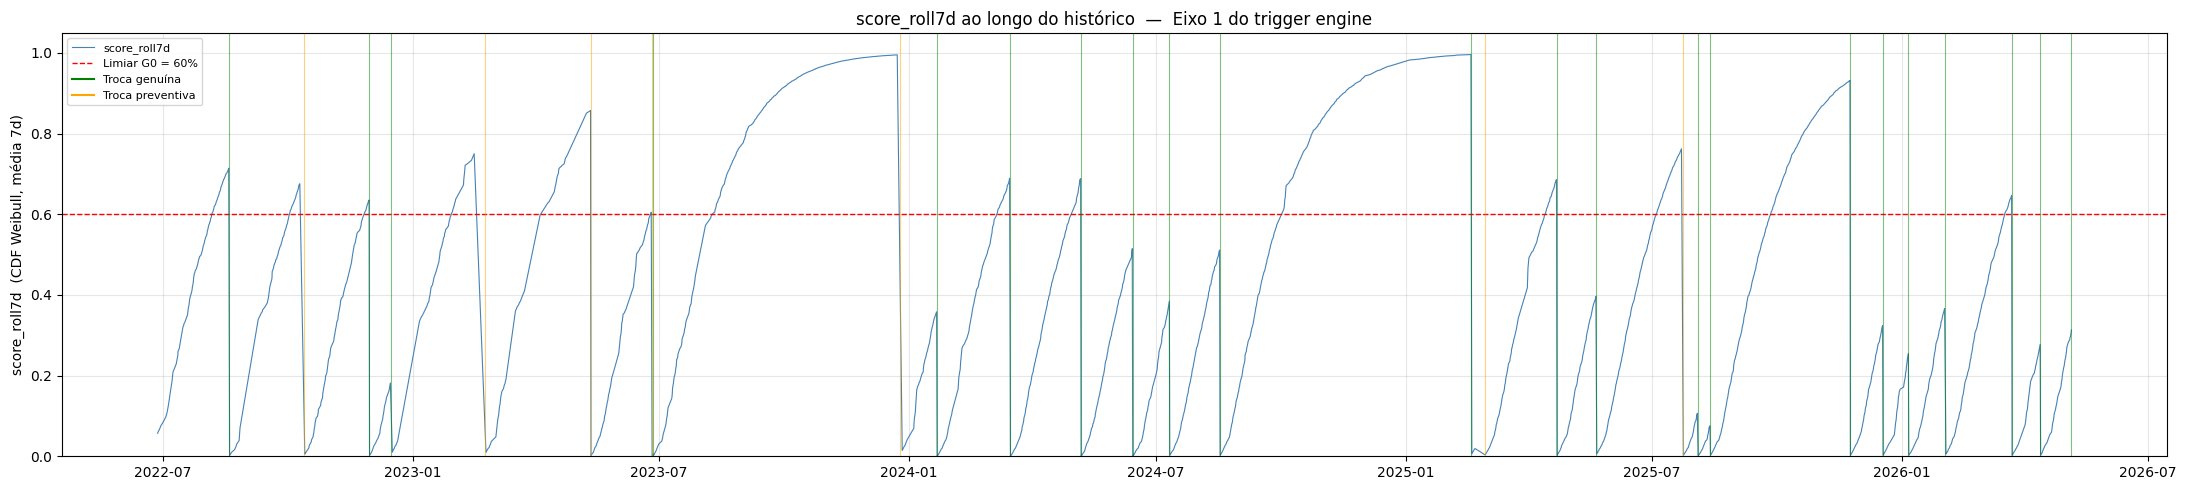

In [ ]:
# Série temporal: score_roll7d com marcadores de troca
fig, ax = plt.subplots(figsize=(22, 5))

mask_plot = df['score_roll7d'].notna()
ax.plot(df.loc[mask_plot, 'ts'], df.loc[mask_plot, 'score_roll7d'],
        lw=0.8, color='steelblue', label='score_roll7d')
ax.axhline(SCORE_CRITICO, color='red', ls='--', lw=1.0,
           label=f'Limiar G0 = {SCORE_CRITICO:.0%}')

for _, row in ciclos_df.iterrows():
    t = pd.Timestamp(row['troca_fim']).tz_localize('UTC')
    cor = 'green' if row['genuino'] else 'orange'
    ax.axvline(t, color=cor, lw=0.8, alpha=0.5)

# Legenda manual para trocas
from matplotlib.lines import Line2D
handles, labels = ax.get_legend_handles_labels()
handles += [Line2D([0], [0], color='green', lw=1.5, label='Troca genuína'),
            Line2D([0], [0], color='orange', lw=1.5, label='Troca preventiva')]
ax.legend(handles=handles, fontsize=8)
ax.set_ylabel('score_roll7d  (CDF Weibull, média 7d)')
ax.set_title('score_roll7d ao longo do histórico  —  Eixo 1 do trigger engine')
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('01_score_roll7d_series.png', dpi=120, bbox_inches='tight')
plt.show()

## Etapa F — Exportar

In [ ]:
cols_export = [
    'ts', 'horas_desde_troca', 'horas_op_desde_troca', 'ciclo_id',
    'score_weibull', 'score_roll7d',
    'rul_p10', 'rul_p50', 'rul_p90',
]

out = df[[c for c in cols_export if c in df.columns]].copy()
out = out.rename(columns={'ts': 'Timestamp'})
out.to_csv('01_vida_rul.csv', index=False)
print(f'Exportado: 01_vida_rul.csv  ({len(out)} linhas)')
print(out.tail(3).round(3).to_string())

params = {
    'weibull_beta'           : round(float(beta), 6),
    'weibull_eta_h'          : round(float(eta), 2),
    'limiar_genuino_h'       : LIMIAR_GENUINO_H,
    'n_ciclos_genuinos'      : int(len(duracoes_h)),
    'score_critico'          : SCORE_CRITICO,
    'h_score_cruza_60pct'    : round(float(h_score_critico), 1),
    'dias_score_cruza_60pct' : round(float(h_score_critico) / 24, 1),
    'vida_p10_h'             : round(float(vida_p10), 1),
    'vida_p50_h'             : round(float(vida_p50), 1),
    'vida_p90_h'             : round(float(vida_p90), 1),
    'cobertura_eixo1_pct'    : round(float(cruzou / len(ant_df) * 100), 1),
    'antecedencia_mediana_d' : round(float(ants.median()), 1) if cruzou > 0 else None,
}

with open('01_weibull_params.json', 'w') as f:
    json.dump(params, f, indent=2)
print('\nExportado: 01_weibull_params.json')
print(json.dumps(params, indent=2))

Exportado: 01_vida_rul.csv  (2978 linhas)
                     Timestamp  horas_desde_troca  ciclo_id  score_weibull  score_roll7d  rul_p10  rul_p50   rul_p90
2975 2026-05-05 07:02:47+00:00            535.046        29          0.355         0.298  104.153  635.572  1894.926
2976 2026-05-05 15:04:59+00:00            543.083        29          0.360         0.304  103.859  634.352  1892.731
2977 2026-05-05 23:02:22+00:00            551.039        29          0.365         0.313  103.572  633.156  1890.574

Exportado: 01_weibull_params.json
{
  "weibull_beta": 1.211573,
  "weibull_eta_h": 1057.3,
  "limiar_genuino_h": 20,
  "n_ciclos_genuinos": 22,
  "score_critico": 0.6,
  "h_score_cruza_60pct": 983.7,
  "dias_score_cruza_60pct": 41.0,
  "vida_p10_h": 165.0,
  "vida_p50_h": 781.3,
  "vida_p90_h": 2104.6,
  "cobertura_eixo1_pct": 36.4,
  "antecedencia_mediana_d": 9.2
}
